# Distribution Shift Controls for Cross-Persona Probe Transfer

Five analyses to disentangle genuine shared encoding from distributional shift:

1. **Mean-centered probe transfer** — subtract each persona's activation mean before training/transferring probes
2. **CCA / Procrustes alignment** — compare representational geometry between personas
3. **Joint-persona probe** — train a single probe on both personas (controlling for persona as nuisance variable)
4. **Persona-direction projection** — project out the persona identity direction, then retrain/transfer
5. **Logit lens convergence** — whether intermediate representations converge on the same answer tokens

## 0. Setup & Data Loading

In [1]:
import json
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn.functional as F
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cross_decomposition import CCA
from scipy.spatial import procrustes
from scipy.linalg import orthogonal_procrustes
from tqdm.auto import tqdm

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11
sns.set_style("whitegrid")

# ── CONFIG: change this path to analyze a different run ─────────────────
RUN_DIR = Path("results/raw/activation_probing_20260304_221155 dolphin 24b")

# ── Auto-resolve paths ──────────────────────────────────────────────────
for base in [Path.cwd(), Path.cwd().parent]:
    if (base / RUN_DIR).exists():
        RUN_DIR = base / RUN_DIR
        break

assert RUN_DIR.exists(), f"Run directory not found: {RUN_DIR}"

def _model_footer(fig, label, y=-0.04):
    fig.text(0.5, y, label, ha="center", va="top", fontsize=9, color="dimgray")

print(f"Run directory: {RUN_DIR}")

Run directory: /Users/daylight/dev/code/cross_persona_introspection/results/raw/activation_probing_20260304_221155 dolphin 24b


In [2]:
# ── Load metadata ───────────────────────────────────────────────────────
with open(RUN_DIR / "metadata.json") as f:
    meta = json.load(f)

MODEL_NAME = meta["model_name"]
N_QUESTIONS = meta["n_questions"]
N_LAYERS = meta["n_layers"]
D_MODEL = meta["d_model"]
PERSONAS = meta["persona_names"]
QUESTION_IDS = meta["question_ids"]
P1, P2 = PERSONAS

print(f"Model: {MODEL_NAME}")
print(f"Personas: {P1} vs {P2}")
print(f"Questions: {N_QUESTIONS}, Layers: {N_LAYERS}, d_model: {D_MODEL}")

# ── Load answer tables ──────────────────────────────────────────────────
logits_df = pd.read_csv(RUN_DIR / "answer_logits.csv")
paired_df = pd.read_csv(RUN_DIR / "paired_answers.csv")

# ── Load activation tensors ────────────────────────────────────────────
activations = {}
for p in PERSONAS:
    safe = p.replace(" ", "_")
    activations[p] = torch.load(RUN_DIR / f"activations_{safe}.pt", map_location="cpu", weights_only=True)
    print(f"activations[{p}] shape: {activations[p].shape}")

# ── Load logit lens tensors ────────────────────────────────────────────
logit_lens = {}
for p in PERSONAS:
    safe = p.replace(" ", "_")
    logit_lens[p] = torch.load(RUN_DIR / f"logit_lens_{safe}.pt", map_location="cpu", weights_only=True)
    print(f"logit_lens[{p}] shape: {logit_lens[p].shape}")

# ── Prepare labels and splits ──────────────────────────────────────────
answers = {}
for p in PERSONAS:
    sub = logits_df[logits_df["persona"] == p].sort_values("question_id")
    answers[p] = sub.set_index("question_id").loc[QUESTION_IDS, "chosen_answer"].values

le = LabelEncoder()
le.fit(np.concatenate([answers[p] for p in PERSONAS]))
labels = {p: le.transform(answers[p]) for p in PERSONAS}

# Agreement / disagreement masks
agree_mask = np.array(paired_df.set_index("question_id").loc[QUESTION_IDS, "is_agreement"].values, dtype=bool)
disagree_mask = np.array(paired_df.set_index("question_id").loc[QUESTION_IDS, "is_disagreement"].values, dtype=bool)

# 60/20/20 split (same as main analysis)
rng = np.random.RandomState(42)
indices = np.arange(N_QUESTIONS)
rng.shuffle(indices)
n_test = max(1, int(0.2 * N_QUESTIONS))
n_val = max(1, int(0.2 * N_QUESTIONS))
train_idx = indices[:N_QUESTIONS - n_val - n_test]
val_idx = indices[N_QUESTIONS - n_val - n_test:N_QUESTIONS - n_test]
test_idx = indices[N_QUESTIONS - n_test:]

test_agree = agree_mask[test_idx]
test_disagree = disagree_mask[test_idx]

print(f"\nSplit: train={len(train_idx)}, val={len(val_idx)}, test={len(test_idx)}")
print(f"Test set: {test_agree.sum()} agreement, {test_disagree.sum()} disagreement")

C_VALUES = [0.01, 0.1, 1.0, 10.0]
layers = np.arange(N_LAYERS)

Model: dphn/Dolphin-Mistral-24B-Venice-Edition
Personas: persona_conservative vs persona_progressive
Questions: 205, Layers: 41, d_model: 5120
activations[persona_conservative] shape: torch.Size([205, 41, 5120])
activations[persona_progressive] shape: torch.Size([205, 41, 5120])
logit_lens[persona_conservative] shape: torch.Size([205, 41, 4])
logit_lens[persona_progressive] shape: torch.Size([205, 41, 4])

Split: train=123, val=41, test=41
Test set: 13 agreement, 28 disagreement


## 5. Linear Probes

We train logistic regression classifier linear probes using the separate script `scripts/train_probes.py`, which saves results to `<run_dir>/probes/`. This notebook **loads** those pre-computed results rather than retraining, ensuring a single source of truth.

**Two key probe types:**
- **Same-persona:** Train on Persona A's activations, predict Persona A's answers. High accuracy = the answer is linearly decodable.
- **Cross-persona:** Train on Persona A's activations, then evaluate on Persona B's activations while still scoring against Persona A's labels. High accuracy would mean both personas encode the same answer information. Low accuracy (especially on disagreement questions) means the personas encode genuinely different answers.

Run probes first: `python scripts/train_probes.py <run_dir>`

In [3]:
# ── Load pre-computed probes OR train inline ─────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tqdm.auto import tqdm

probes_dir = RUN_DIR / "probes"
metrics_path = probes_dir / "probe_metrics.csv"

if metrics_path.exists():
    # ── LOAD from train_probes.py output ──────────────────────────────
    probe_metrics = pd.read_csv(metrics_path)
    print(f"Loaded {len(probe_metrics)} probe metric rows from {metrics_path}")

    predictions_path = probes_dir / "probe_predictions.csv"
    if predictions_path.exists():
        probe_predictions = pd.read_csv(predictions_path)
        print(f"Loaded {len(probe_predictions)} prediction rows")
    else:
        probe_predictions = None

    manifest_path = probes_dir / "split_manifest.json"
    if manifest_path.exists():
        with open(manifest_path) as f:
            split_manifest = json.load(f)
        print(f"Split: train={split_manifest['n_train']}, "
              f"val={split_manifest['n_val']}, test={split_manifest['n_test']}")
else:
    # ── TRAIN inline (no pre-computed probes found) ───────────────────
    print(f"No probes found at {probes_dir}, training inline...")

    answers = {}
    for p in PERSONAS:
        sub = logits_df[logits_df["persona"] == p].sort_values("question_id")
        answers[p] = sub.set_index("question_id").loc[QUESTION_IDS, "chosen_answer"].values

    le = LabelEncoder()
    le.fit(np.concatenate([answers[p] for p in PERSONAS]))
    labels = {p: le.transform(answers[p]) for p in PERSONAS}

    # 60/20/20 split (matches train_probes.py logic)
    rng = np.random.RandomState(42)
    indices = np.arange(N_QUESTIONS)
    rng.shuffle(indices)
    n_test = max(1, int(0.2 * N_QUESTIONS))
    n_val = max(1, int(0.2 * N_QUESTIONS))
    train_idx = indices[:N_QUESTIONS - n_val - n_test]
    val_idx = indices[N_QUESTIONS - n_val - n_test:N_QUESTIONS - n_test]
    test_idx = indices[N_QUESTIONS - n_test:]

    test_agree = agree_mask[test_idx]
    test_disagree = disagree_mask[test_idx]

    print(f"Split: train={len(train_idx)}, val={len(val_idx)}, test={len(test_idx)}")
    print(f"Test set: {test_agree.sum()} agreement, {test_disagree.sum()} disagreement")

    eval_combos = []
    for probe_p in PERSONAS:
        other_p = [p for p in PERSONAS if p != probe_p][0]
        eval_combos.append((probe_p, probe_p, "same_persona"))
        eval_combos.append((probe_p, other_p, "cross_persona"))

    C_VALUES = [0.01, 0.1, 1.0, 10.0]
    metric_rows = []

    for layer in tqdm(range(N_LAYERS), desc="Training probes"):
        probes_dict = {}
        scalers_dict = {}

        for pname in PERSONAS:
            X_all = activations[pname][:, layer, :].float().numpy()
            y_all = labels[pname]

            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_all[train_idx])
            X_val = scaler.transform(X_all[val_idx])
            y_train, y_val = y_all[train_idx], y_all[val_idx]

            best_score, best_clf = -1.0, None
            for C in C_VALUES:
                clf = LogisticRegression(C=C, max_iter=2000, solver="lbfgs", random_state=42)
                clf.fit(X_train, y_train)
                score = clf.score(X_val, y_val)
                if score > best_score:
                    best_score = score
                    best_clf = clf

            probes_dict[pname] = best_clf
            scalers_dict[pname] = scaler

        for probe_p, act_p, combo_type in eval_combos:
            probe = probes_dict[probe_p]
            scaler = scalers_dict[probe_p]
            X_test = scaler.transform(activations[act_p][:, layer, :].float().numpy()[test_idx])
            y_test = labels[probe_p][test_idx]

            for subset_name, subset_mask in [("full", None), ("agreement", test_agree),
                                              ("disagreement", test_disagree)]:
                if subset_mask is not None:
                    if subset_mask.sum() == 0:
                        continue
                    acc = float(probe.score(X_test[subset_mask], y_test[subset_mask]))
                    n_s = int(subset_mask.sum())
                else:
                    acc = float(probe.score(X_test, y_test))
                    n_s = len(y_test)
                metric_rows.append({
                    "layer": layer, "probe_persona": probe_p,
                    "activation_persona": act_p, "combo_type": combo_type,
                    "subset": subset_name, "accuracy": acc, "n_samples": n_s,
                })

    probe_metrics = pd.DataFrame(metric_rows)
    print(f"Trained probes at all {N_LAYERS} layers. {len(probe_metrics)} metric rows.")

# Quick summary
for combo in probe_metrics["combo_type"].unique():
    sub = probe_metrics[(probe_metrics["combo_type"] == combo) &
                        (probe_metrics["subset"] == "full")]
    final = sub[sub["layer"] == sub["layer"].max()]
    mean_acc = final["accuracy"].mean()
    print(f"  {combo:15s} final-layer accuracy (full): {mean_acc:.3f}")

No probes found at /Users/daylight/dev/code/cross_persona_introspection/results/raw/activation_probing_20260304_221155 dolphin 24b/probes, training inline...
Split: train=123, val=41, test=41
Test set: 13 agreement, 28 disagreement


Training probes:   0%|          | 0/41 [00:00<?, ?it/s]

Trained probes at all 41 layers. 492 metric rows.
  same_persona    final-layer accuracy (full): 1.000
  cross_persona   final-layer accuracy (full): 0.317


### Probe accuracy by layer

**Left panel (full):** Accuracy on all test questions. Solid lines = same-persona (baseline), dashed = cross-persona.

**Right panel (disagreement):** Accuracy only on questions where the personas gave different final answers. This is the most informative subset — on agreement questions, cross-persona probes trivially work since both personas chose the same answer.

**What to look for:**
- Same-persona accuracy should rise from chance (0.25) to near 1.0 in later layers
- The key question is the **gap** between solid and dashed lines in the disagreement panel. A large gap = deep persona effects. A small gap = shallow.

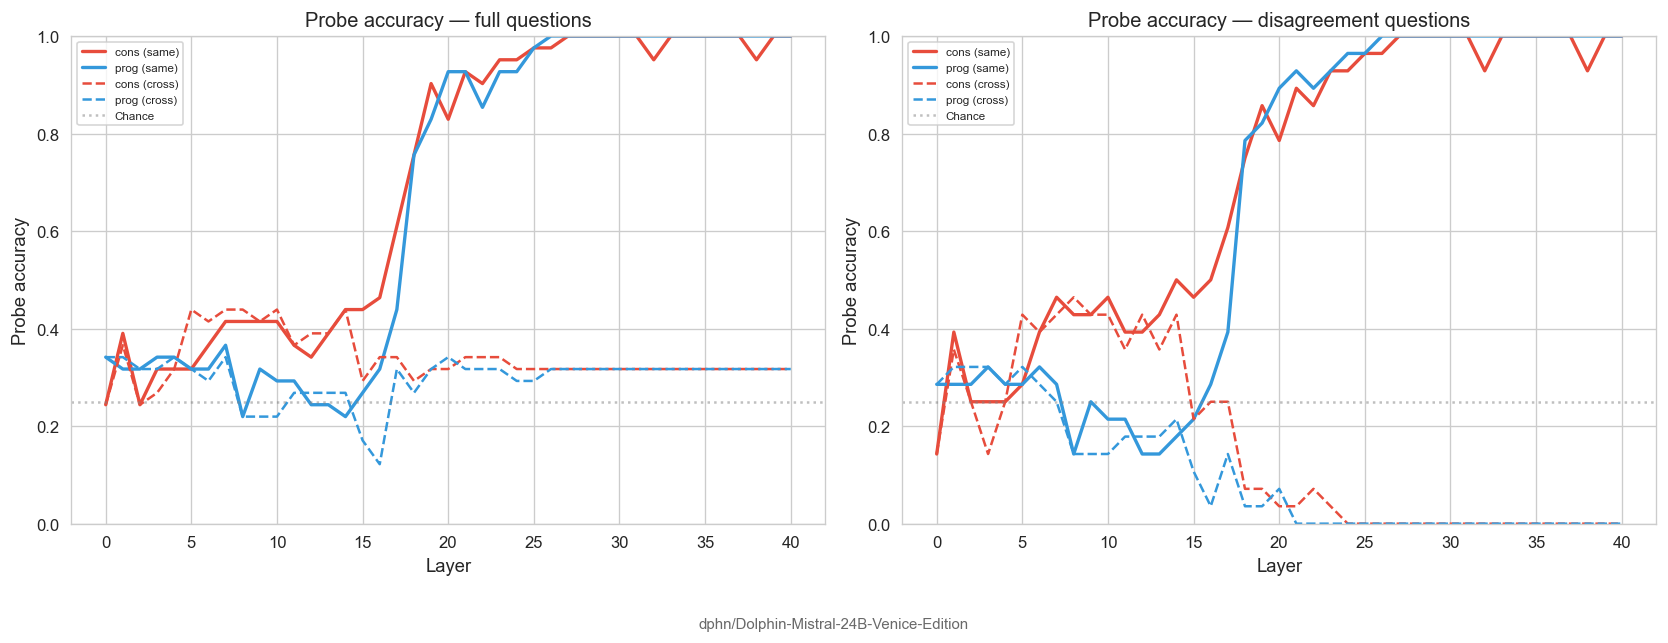

In [4]:
# ── Same-persona vs cross-persona probe accuracy by layer ─────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, subset in zip(axes, ["full", "disagreement"]):
    sub = probe_metrics[probe_metrics["subset"] == subset]
    if sub.empty:
        ax.text(0.5, 0.5, f"No data for subset '{subset}'", ha="center")
        continue

    for combo_type, style, width in [("same_persona", "-", 2), ("cross_persona", "--", 1.5)]:
        combo_sub = sub[sub["combo_type"] == combo_type]
        for p, color in zip(PERSONAS, ["#e74c3c", "#3498db"]):
            p_sub = combo_sub[combo_sub["probe_persona"] == p].sort_values("layer")
            if p_sub.empty:
                continue
            label = f"{p.replace('persona_','')[:4]} ({combo_type.replace('_persona','')})"
            ax.plot(p_sub["layer"], p_sub["accuracy"], linestyle=style,
                    linewidth=width, color=color, label=label)

    ax.axhline(0.25, color="gray", linestyle=":", alpha=0.5, label="Chance")
    ax.set_xlabel("Layer")
    ax.set_ylabel("Probe accuracy")
    ax.set_title(f"Probe accuracy \u2014 {subset} questions")
    ax.legend(fontsize=7)
    ax.set_ylim(0, 1)

_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

### Probe accuracy gap (same minus cross)

This directly plots the difference: same-persona accuracy minus cross-persona accuracy at each layer.

- **Positive gap** = the model's hidden states encode persona-specific information that doesn't transfer to the other persona. The persona has changed the internal representation.
- **Gap near zero** = the hidden states are interchangeable between personas. The persona effect is shallow.
- **Solid line** = all questions. **Dashed line** = disagreement questions only (more informative).

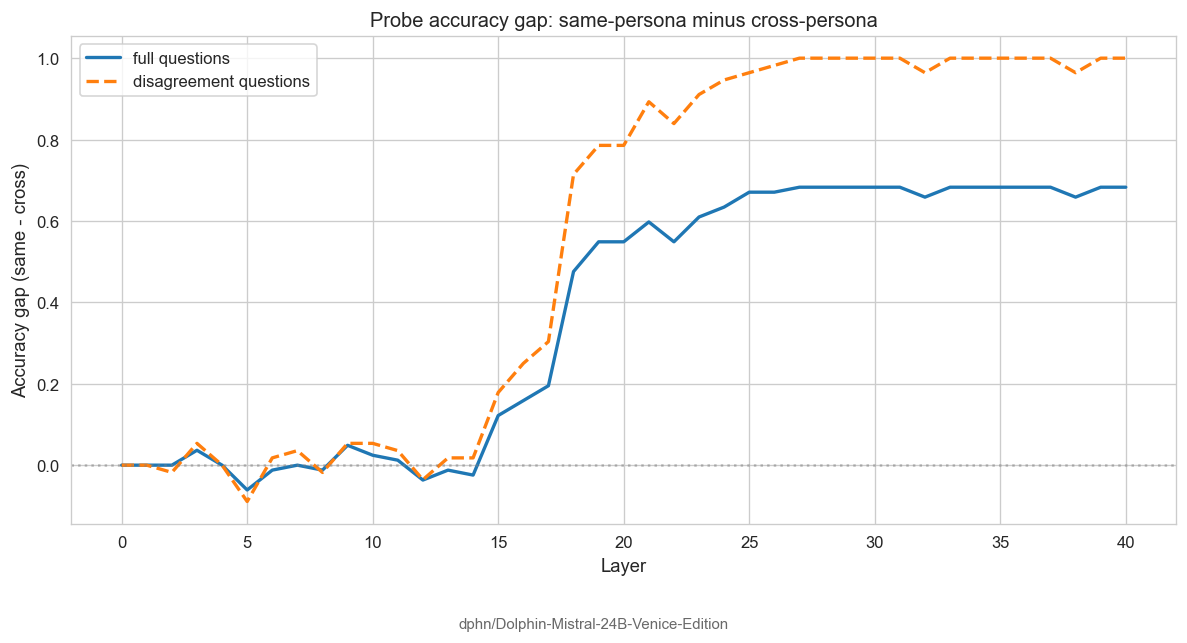

Positive gap = activations encode persona-specific answer information.
Negative gap = other persona's activations are MORE informative (unlikely).


In [5]:
# ── Probe accuracy gap: same - cross persona ──────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

for subset, style in [("full", "-"), ("disagreement", "--")]:
    sub = probe_metrics[probe_metrics["subset"] == subset]
    if sub.empty:
        continue
    same = sub[sub["combo_type"] == "same_persona"].groupby("layer")["accuracy"].mean()
    cross = sub[sub["combo_type"] == "cross_persona"].groupby("layer")["accuracy"].mean()
    gap = same - cross
    gap = gap.dropna()
    ax.plot(gap.index, gap.values, linestyle=style, linewidth=2, label=f"{subset} questions")

ax.axhline(0, color="gray", linestyle=":", alpha=0.5)
ax.set_xlabel("Layer")
ax.set_ylabel("Accuracy gap (same - cross)")
ax.set_title("Probe accuracy gap: same-persona minus cross-persona")
ax.legend()
_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

print("Positive gap = activations encode persona-specific answer information.")
print("Negative gap = other persona's activations are MORE informative (unlikely).")

### Persona identity probe: is the persona itself encoded in activations?

A different probe: given a hidden state vector, can we tell whether it came from the conservative or progressive persona? This is a binary classification (50% chance baseline).

- **High accuracy** (near 100%) = the model's internal state is measurably different between personas at that layer. The system prompt has left a "fingerprint" in the hidden states.
- **Near chance** (50%) = the hidden states are indistinguishable between personas at that layer.

**Note:** High persona identity accuracy doesn't necessarily mean the *answer* differs — even on agreement questions, the system prompt text is different, so early layers will likely show high identity accuracy just from the prompt tokens. The interesting signal is whether identity accuracy *stays* high through the later layers where the model is computing its answer.

In [6]:
# ── Persona identity probe: can we tell WHICH persona from activations? ─
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

id_layers = sorted(set([0] + list(range(0, N_LAYERS, 2)) + [N_LAYERS - 1]))
id_results = []

rng = np.random.RandomState(42)
indices = np.arange(N_QUESTIONS)
rng.shuffle(indices)
n_train = int(0.7 * N_QUESTIONS)
train_idx_id = indices[:n_train]
test_idx_id = indices[n_train:]

for layer in id_layers:
    x1 = act_p1[:, layer, :].numpy()
    x2 = act_p2[:, layer, :].numpy()
    X_train = np.concatenate([x1[train_idx_id], x2[train_idx_id]], axis=0)
    y_train = np.array([0] * len(train_idx_id) + [1] * len(train_idx_id))
    X_test = np.concatenate([x1[test_idx_id], x2[test_idx_id]], axis=0)
    y_test = np.array([0] * len(test_idx_id) + [1] * len(test_idx_id))

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    clf = LogisticRegression(C=1.0, max_iter=2000, random_state=42)
    clf.fit(X_train_s, y_train)
    acc = clf.score(X_test_s, y_test)
    id_results.append({"layer": layer, "accuracy": acc})

id_df = pd.DataFrame(id_results)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(id_df["layer"], id_df["accuracy"], "o-", color="purple", linewidth=2, markersize=4)
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Chance (0.5)")
ax.set_xlabel("Layer")
ax.set_ylabel("Accuracy")
ax.set_title("Persona identity probe: can we tell conservative from progressive?")
ax.legend()
ax.set_ylim(0.4, 1.05)
_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

print(f"Final layer persona identification accuracy: {id_df.iloc[-1]['accuracy']:.3f}")

NameError: name 'act_p1' is not defined

### Cross-persona answer probe: is the *other* persona's answer encoded in your activations?

**What this tests:** Train a probe on persona A's activations to predict persona **B's** answer
(not A's own). This is different from the cross-transfer test above:

- **Cross-transfer** asks: "do the same features encode answers across personas?"
  (train on A's acts → A's labels, evaluate on B's acts → A's labels)
- **This probe** asks: "is B's answer *anywhere* in A's activation space, possibly in a
  different subspace?" (train on A's acts → **B's labels**)

If this probe succeeds where cross-transfer failed, that's a direct demonstration of
**privileged access**: persona A's computation contains information about persona B's
answer, just not in the same representation used for A's own answer.

In [ ]:
# ── Cross-persona answer probe: predict OTHER persona's answer ────────
# For each persona A, train a probe on A's activations to predict B's labels.
# Compare with: (1) same-persona probe (A acts → A labels) as upper bound,
#               (2) cross-transfer probe (A acts → B acts, same probe) as baseline,
#               (3) chance (0.25 for 4-way).

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Prepare labels
answers = {}
for p in PERSONAS:
    sub = logits_df[logits_df["persona"] == p].sort_values("question_id")
    answers[p] = sub.set_index("question_id").loc[QUESTION_IDS, "chosen_answer"].values

le_cross = LabelEncoder()
le_cross.fit(np.concatenate([answers[p] for p in PERSONAS]))
labels_cross = {p: le_cross.transform(answers[p]) for p in PERSONAS}

# Use same train/test split as main probes
rng = np.random.RandomState(42)
indices = np.arange(N_QUESTIONS)
rng.shuffle(indices)
n_test = max(1, int(0.2 * N_QUESTIONS))
n_val = max(1, int(0.2 * N_QUESTIONS))
train_idx_cp = indices[:N_QUESTIONS - n_val - n_test]
val_idx_cp = indices[N_QUESTIONS - n_val - n_test:N_QUESTIONS - n_test]
test_idx_cp = indices[N_QUESTIONS - n_test:]

test_agree_cp = agree_mask.numpy()[test_idx_cp]
test_disagree_cp = disagree_mask.numpy()[test_idx_cp]

C_VALUES = [0.01, 0.1, 1.0, 10.0]
cross_answer_rows = []

for layer in tqdm(range(N_LAYERS), desc="Cross-answer probes"):
    for act_persona in PERSONAS:
        other_persona = [p for p in PERSONAS if p != act_persona][0]

        X_all = activations[act_persona][:, layer, :].float().numpy()
        # Target: the OTHER persona's answer
        y_other_all = labels_cross[other_persona]
        # Also keep same-persona labels for comparison
        y_same_all = labels_cross[act_persona]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_all[train_idx_cp])
        X_val = scaler.transform(X_all[val_idx_cp])
        X_test = scaler.transform(X_all[test_idx_cp])

        for target_name, y_all in [("other_answer", y_other_all), ("own_answer", y_same_all)]:
            y_train, y_val, y_test = y_all[train_idx_cp], y_all[val_idx_cp], y_all[test_idx_cp]

            # Hyperparameter selection on val set
            best_score, best_clf = -1.0, None
            for C in C_VALUES:
                clf = LogisticRegression(C=C, max_iter=2000, solver="lbfgs", random_state=42)
                clf.fit(X_train, y_train)
                score = clf.score(X_val, y_val)
                if score > best_score:
                    best_score = score
                    best_clf = clf

            for subset_name, mask in [("full", None), ("agreement", test_agree_cp),
                                       ("disagreement", test_disagree_cp)]:
                if mask is not None:
                    if mask.sum() == 0:
                        continue
                    acc = float(best_clf.score(X_test[mask], y_test[mask]))
                    n_s = int(mask.sum())
                else:
                    acc = float(best_clf.score(X_test, y_test))
                    n_s = len(y_test)

                cross_answer_rows.append({
                    "layer": layer,
                    "activation_persona": act_persona,
                    "target": target_name,
                    "subset": subset_name,
                    "accuracy": acc,
                    "n_samples": n_s,
                })

cross_answer_df = pd.DataFrame(cross_answer_rows)
print(f"Cross-answer probe: {len(cross_answer_df)} metric rows")

# Final-layer summary
for target in ["own_answer", "other_answer"]:
    for subset in ["full", "disagreement"]:
        sub = cross_answer_df[(cross_answer_df["layer"] == N_LAYERS - 1) &
                              (cross_answer_df["target"] == target) &
                              (cross_answer_df["subset"] == subset)]
        if not sub.empty:
            mean_acc = sub["accuracy"].mean()
            print(f"  {target:15s} ({subset:12s}): {mean_acc:.3f}")

AttributeError: 'numpy.ndarray' object has no attribute 'numpy'

NameError: name 'cross_answer_df' is not defined

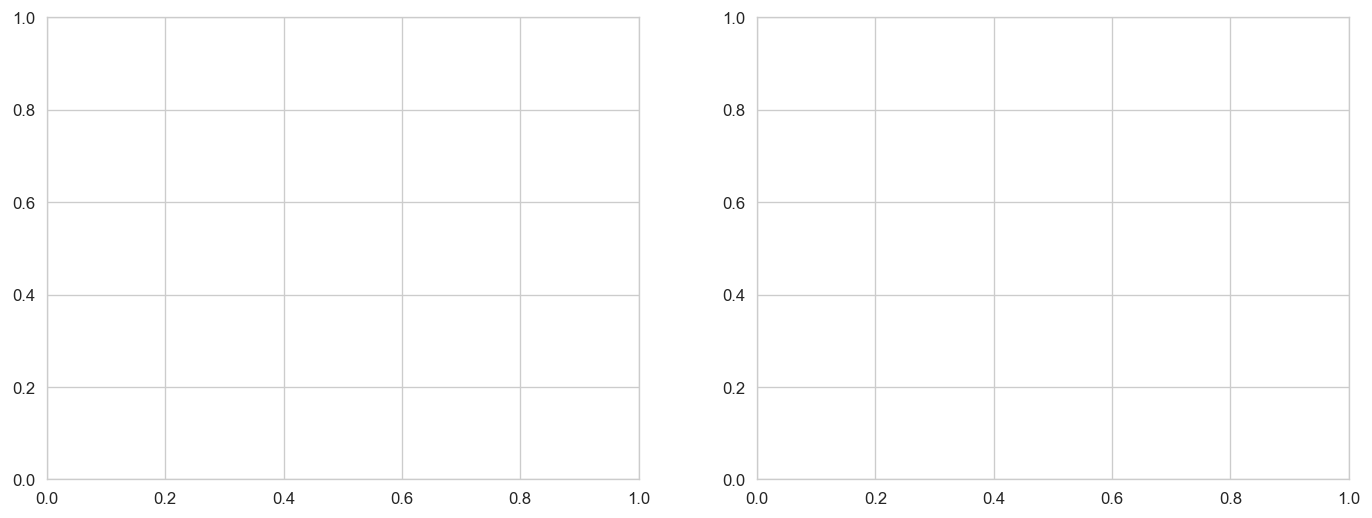

In [ ]:
# ── Plot: cross-answer probe accuracy by layer ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {"own_answer": "#2ecc71", "other_answer": "#e67e22"}
styles = {"own_answer": "-", "other_answer": "--"}

for ax, subset in zip(axes, ["full", "disagreement"]):
    sub = cross_answer_df[cross_answer_df["subset"] == subset]
    if sub.empty:
        ax.text(0.5, 0.5, f"No data for subset '{subset}'", ha="center")
        continue

    for target in ["own_answer", "other_answer"]:
        t_sub = sub[sub["target"] == target].groupby("layer")["accuracy"].mean()
        label_nice = "own answer (baseline)" if target == "own_answer" else "OTHER persona's answer"
        ax.plot(t_sub.index, t_sub.values, linestyle=styles[target],
                linewidth=2, color=colors[target], label=label_nice)

    # Also show cross-transfer from main probes for comparison
    cross_transfer = probe_metrics[(probe_metrics["subset"] == subset) &
                                    (probe_metrics["combo_type"] == "cross_persona")]
    if not cross_transfer.empty:
        ct_mean = cross_transfer.groupby("layer")["accuracy"].mean()
        ax.plot(ct_mean.index, ct_mean.values, linestyle=":", linewidth=1.5,
                color="#9b59b6", label="cross-transfer (reference)")

    ax.axhline(0.25, color="gray", linestyle=":", alpha=0.5, label="Chance")
    ax.set_xlabel("Layer")
    ax.set_ylabel("Probe accuracy")
    ax.set_title(f"Cross-answer probe — {subset} questions")
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1)

_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

# ── Privileged access gap ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
for subset, style in [("full", "-"), ("disagreement", "--")]:
    sub = cross_answer_df[cross_answer_df["subset"] == subset]
    other_acc = sub[sub["target"] == "other_answer"].groupby("layer")["accuracy"].mean()

    # Cross-transfer from main probes
    ct = probe_metrics[(probe_metrics["subset"] == subset) &
                        (probe_metrics["combo_type"] == "cross_persona")]
    ct_acc = ct.groupby("layer")["accuracy"].mean()

    # Privileged access = other_answer probe - cross_transfer
    common_layers = other_acc.index.intersection(ct_acc.index)
    if len(common_layers) > 0:
        gap = other_acc[common_layers] - ct_acc[common_layers]
        ax.plot(gap.index, gap.values, linestyle=style, linewidth=2,
                label=f"{subset} questions")

ax.axhline(0, color="gray", linestyle=":", alpha=0.5)
ax.set_xlabel("Layer")
ax.set_ylabel("Accuracy gap (other-answer probe − cross-transfer)")
ax.set_title("Privileged access signal: can A's activations predict B's answer\n"
             "better when trained directly vs. transferred?")
ax.legend()
_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

print("Positive gap = A's activations encode B's answer in a DIFFERENT subspace")
print("  than A uses for its own answer (privileged access).")
print("Zero/negative gap = no evidence of privileged access beyond shared features.")

### Baseline check: A-answer-only prediction of B's answer

The cross-answer probe above shows that A's activations can predict B's answer. But how much
of that is just because **A's own answer correlates with B's answer**? (e.g., if A picks "C",
maybe B usually picks "D" — a simple lookup table could capture that.)

**Test:** Build a 4x4 mapping from A's answer to B's most-common answer on the training set,
then apply it to the test set. If the activation-based probe barely beats this baseline,
it's mostly exploiting answer correlations. If it beats it clearly, the activations contain
**extra information about B's answer beyond what A's own answer reveals**.

In [ ]:
# ── A-answer-only baseline: predict B's answer from A's answer alone ──
# For each persona A, build a lookup table A_answer → most_common(B_answer)
# on the training set, then evaluate on the test set.

from collections import Counter

baseline_rows = []

for act_persona in PERSONAS:
    other_persona = [p for p in PERSONAS if p != act_persona][0]
    y_a_all = labels_cross[act_persona]    # A's answer (encoded)
    y_b_all = labels_cross[other_persona]  # B's answer (encoded)

    # Build mapping on training set: for each A answer, what's B's most common answer?
    mapping = {}
    for a_ans in np.unique(y_a_all[train_idx_cp]):
        mask_train = y_a_all[train_idx_cp] == a_ans
        if mask_train.sum() > 0:
            counter = Counter(y_b_all[train_idx_cp][mask_train])
            mapping[a_ans] = counter.most_common(1)[0][0]

    # Apply to test set
    y_a_test = y_a_all[test_idx_cp]
    y_b_test = y_b_all[test_idx_cp]
    y_pred_baseline = np.array([mapping.get(a, 0) for a in y_a_test])

    for subset_name, mask in [("full", None), ("agreement", test_agree_cp),
                               ("disagreement", test_disagree_cp)]:
        if mask is not None:
            if mask.sum() == 0:
                continue
            acc = float((y_pred_baseline[mask] == y_b_test[mask]).mean())
            n_s = int(mask.sum())
        else:
            acc = float((y_pred_baseline == y_b_test).mean())
            n_s = len(y_b_test)

        baseline_rows.append({
            "activation_persona": act_persona,
            "subset": subset_name,
            "baseline_accuracy": acc,
            "n_samples": n_s,
        })

baseline_df = pd.DataFrame(baseline_rows)

# Show the mapping tables
for act_persona in PERSONAS:
    other_persona = [p for p in PERSONAS if p != act_persona][0]
    y_a_train = labels_cross[act_persona][train_idx_cp]
    y_b_train = labels_cross[other_persona][train_idx_cp]
    act_short = act_persona.replace("persona_", "")[:12]
    other_short = other_persona.replace("persona_", "")[:12]
    print(f"\nMapping: {act_short}'s answer → {other_short}'s most common answer (train set):")
    for a_ans in sorted(np.unique(y_a_train)):
        mask_t = y_a_train == a_ans
        counter = Counter(y_b_train[mask_t])
        total_t = mask_t.sum()
        a_letter = le_cross.inverse_transform([a_ans])[0]
        top_b = counter.most_common(1)[0]
        b_letter = le_cross.inverse_transform([top_b[0]])[0]
        print(f"  {a_letter} → {b_letter} ({top_b[1]}/{total_t} = {top_b[1]/total_t:.0%})")

# Compare with activation probe at final layer
print(f"\n{'─' * 60}")
print(f"{'Subset':<15s} {'Baseline':<12s} {'Probe (final layer)':<20s} {'Probe − Baseline'}")
print(f"{'─' * 60}")
for subset in ["full", "agreement", "disagreement"]:
    bl = baseline_df[baseline_df["subset"] == subset]["baseline_accuracy"].mean()
    probe_sub = cross_answer_df[(cross_answer_df["layer"] == N_LAYERS - 1) &
                                 (cross_answer_df["target"] == "other_answer") &
                                 (cross_answer_df["subset"] == subset)]
    if not probe_sub.empty:
        pr = probe_sub["accuracy"].mean()
        diff = pr - bl
        marker = " ← activations add info" if diff > 0.03 else ""
        print(f"{subset:<15s} {bl:<12.3f} {pr:<20.3f} {diff:+.3f}{marker}")
    else:
        print(f"{subset:<15s} {bl:<12.3f} {'N/A':<20s}")

In [ ]:
# ── Plot: activation probe vs A-answer-only baseline across layers ────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, subset in zip(axes, ["full", "disagreement"]):
    # Probe accuracy by layer
    probe_sub = cross_answer_df[(cross_answer_df["target"] == "other_answer") &
                                 (cross_answer_df["subset"] == subset)]
    if probe_sub.empty:
        ax.text(0.5, 0.5, f"No data for '{subset}'", ha="center")
        continue
    probe_by_layer = probe_sub.groupby("layer")["accuracy"].mean()
    ax.plot(probe_by_layer.index, probe_by_layer.values, "--", linewidth=2,
            color="#e67e22", label="Activation probe → B's answer")

    # Baseline (flat line — doesn't depend on layer)
    bl = baseline_df[baseline_df["subset"] == subset]["baseline_accuracy"].mean()
    ax.axhline(bl, color="#c0392b", linestyle="-.", linewidth=2,
               label=f"A-answer-only baseline ({bl:.3f})")

    ax.axhline(0.25, color="gray", linestyle=":", alpha=0.5, label="Chance (0.25)")
    ax.set_xlabel("Layer")
    ax.set_ylabel("Accuracy predicting B's answer")
    ax.set_title(f"Probe vs. answer-only baseline — {subset} Qs")
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1)

_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

print("If the orange probe rises well above the red baseline, A's activations")
print("contain information about B's answer BEYOND what A's own answer implies.")

### Stratified-by-A-answer evaluation

The strongest test for whether activations contain extra information: evaluate the
other-answer probe **within each A-answer bucket** (on disagreement questions only).

If A picks "C" and we only look at test questions where A picked "C", can the probe still
predict B's answer above chance? If yes, the probe is using information in the activation
state **beyond** the fact that A chose "C" — ruling out the "A implies B" confound entirely.

In [ ]:
# ── Stratified-by-A-answer: probe accuracy within each A-answer bucket ──
# Train the other-answer probe at each layer (reuse from cross_answer_df training),
# but evaluate separately within each A-answer class on disagreement test questions.

stratified_rows = []

for layer in tqdm(range(N_LAYERS), desc="Stratified evaluation"):
    for act_persona in PERSONAS:
        other_persona = [p for p in PERSONAS if p != act_persona][0]

        X_all = activations[act_persona][:, layer, :].float().numpy()
        y_b_all = labels_cross[other_persona]
        y_a_all = labels_cross[act_persona]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_all[train_idx_cp])
        X_val = scaler.transform(X_all[val_idx_cp])
        X_test = scaler.transform(X_all[test_idx_cp])

        y_b_train = y_b_all[train_idx_cp]
        y_b_val = y_b_all[val_idx_cp]
        y_b_test = y_b_all[test_idx_cp]
        y_a_test = y_a_all[test_idx_cp]

        # Train probe (same as cross-answer probe)
        best_score, best_clf = -1.0, None
        for C in C_VALUES:
            clf = LogisticRegression(C=C, max_iter=2000, solver="lbfgs", random_state=42)
            clf.fit(X_train, y_b_train)
            score = clf.score(X_val, y_b_val)
            if score > best_score:
                best_score = score
                best_clf = clf

        # Evaluate within each A-answer bucket (disagreement only)
        for a_ans in np.unique(y_a_all):
            bucket_mask = test_disagree_cp & (y_a_test == a_ans)
            n_bucket = int(bucket_mask.sum())
            if n_bucket < 3:  # skip tiny buckets
                continue
            acc = float(best_clf.score(X_test[bucket_mask], y_b_test[bucket_mask]))
            a_letter = le_cross.inverse_transform([a_ans])[0]

            # Within-bucket chance: if B's answer has k unique values in this bucket,
            # majority-class baseline
            b_vals = y_b_test[bucket_mask]
            majority_acc = float(Counter(b_vals).most_common(1)[0][1]) / n_bucket

            stratified_rows.append({
                "layer": layer,
                "activation_persona": act_persona,
                "a_answer": a_letter,
                "accuracy": acc,
                "majority_baseline": majority_acc,
                "n_samples": n_bucket,
            })

stratified_df = pd.DataFrame(stratified_rows)
print(f"Stratified evaluation: {len(stratified_df)} rows")

# Final-layer summary
final_strat = stratified_df[stratified_df["layer"] == N_LAYERS - 1]
print(f"\nFinal layer — probe accuracy within each A-answer bucket (disagreement Qs):")
print(f"{'A answer':<10s} {'n':<6s} {'Probe acc':<12s} {'Majority BL':<12s} {'Probe−BL'}")
for a_letter in sorted(final_strat["a_answer"].unique()):
    sub = final_strat[final_strat["a_answer"] == a_letter]
    acc = sub["accuracy"].mean()
    bl = sub["majority_baseline"].mean()
    n = int(sub["n_samples"].sum())
    diff = acc - bl
    marker = " *" if diff > 0.05 else ""
    print(f"{a_letter:<10s} {n:<6d} {acc:<12.3f} {bl:<12.3f} {diff:+.3f}{marker}")

In [ ]:
# ── Plot: stratified probe accuracy by layer per A-answer bucket ──────
a_answers = sorted(stratified_df["a_answer"].unique())
n_buckets = len(a_answers)

fig, axes = plt.subplots(1, min(n_buckets, 4), figsize=(4 * min(n_buckets, 4), 5),
                          squeeze=False)
axes = axes.flatten()

colors_strat = plt.cm.Set2(np.linspace(0, 1, n_buckets))

for i, a_letter in enumerate(a_answers[:4]):
    ax = axes[i]
    sub = stratified_df[stratified_df["a_answer"] == a_letter]
    by_layer = sub.groupby("layer").agg(
        acc_mean=("accuracy", "mean"),
        bl_mean=("majority_baseline", "mean"),
        n_total=("n_samples", "sum"),
    ).reset_index()

    ax.plot(by_layer["layer"], by_layer["acc_mean"], "-", linewidth=2,
            color=colors_strat[i], label=f"Probe (A={a_letter})")
    ax.plot(by_layer["layer"], by_layer["bl_mean"], ":", linewidth=1.5,
            color="gray", label=f"Majority BL (A={a_letter})")
    ax.axhline(0.25, color="lightgray", linestyle=":", alpha=0.5)
    ax.set_xlabel("Layer")
    ax.set_ylabel("Accuracy")
    n_avg = int(by_layer["n_total"].iloc[0]) if len(by_layer) > 0 else 0
    ax.set_title(f"A answered '{a_letter}'\n(n≈{n_avg} per persona)")
    ax.legend(fontsize=7)
    ax.set_ylim(0, 1)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Stratified other-answer probe: accuracy within each A-answer bucket\n"
             "(disagreement Qs only)", fontsize=12, y=1.02)
_model_footer(fig, MODEL_NAME, y=-0.06)
plt.tight_layout()
plt.show()

# ── Summary bar chart at final layer ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
final_strat = stratified_df[stratified_df["layer"] == N_LAYERS - 1]
summary = final_strat.groupby("a_answer").agg(
    acc=("accuracy", "mean"),
    bl=("majority_baseline", "mean"),
    n=("n_samples", "sum"),
).reset_index()

x = np.arange(len(summary))
w = 0.35
bars1 = ax.bar(x - w/2, summary["acc"], w, label="Probe accuracy", color="#e67e22", alpha=0.8)
bars2 = ax.bar(x + w/2, summary["bl"], w, label="Majority baseline", color="#95a5a6", alpha=0.8)

for bar, val in zip(bars1, summary["acc"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.2f}", ha="center", fontsize=9)
for bar, val in zip(bars2, summary["bl"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.2f}", ha="center", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f"{r['a_answer']}\n(n={int(r['n'])})" for _, r in summary.iterrows()])
ax.set_xlabel("A's answer (bucket)")
ax.set_ylabel("Accuracy predicting B's answer")
ax.set_title("Final layer: stratified other-answer probe vs majority baseline\n"
             "(disagreement questions only)")
ax.legend()
ax.set_ylim(0, 1)
_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

# Interpretation
above_bl = (summary["acc"] - summary["bl"]).mean()
n_above = (summary["acc"] > summary["bl"] + 0.05).sum()
print(f"\nMean probe − baseline across buckets: {above_bl:+.3f}")
print(f"Buckets where probe > baseline + 5%: {n_above}/{len(summary)}")
if n_above > len(summary) // 2:
    print("→ Activations contain info about B's answer BEYOND A's own answer choice.")
    print("  This rules out the 'A implies B' confound.")
else:
    print("→ Probe advantage within buckets is weak or absent.")
    print("  The cross-answer probe may mostly exploit A→B answer correlations.")

## 1. Mean-Centered Probe Transfer

If persona just shifts activations to a different region but the answer-relevant directions
are the same, mean-centering should recover transfer performance. We subtract each persona's
per-layer activation mean (computed on training set) before training and evaluating probes.

Compare:
- **Raw transfer** (baseline) — train on A, test on B, no centering
- **Mean-centered transfer** — center each persona by its own mean, then transfer
- **Same-persona** — upper bound

In [ ]:
# ── Mean-centered probe transfer ─────────────────────────────────────
mc_rows = []

for layer in tqdm(range(N_LAYERS), desc="Mean-centered probes"):
    # Extract activations for this layer
    act = {}
    act_centered = {}
    for p in PERSONAS:
        X = activations[p][:, layer, :].float().numpy()
        act[p] = X
        # Compute mean from training set only (no leakage)
        train_mean = X[train_idx].mean(axis=0)
        act_centered[p] = X - train_mean

    for probe_p in PERSONAS:
        other_p = [p for p in PERSONAS if p != probe_p][0]

        for centering_name, X_dict in [("raw", act), ("mean_centered", act_centered)]:
            # Train probe on probe_p
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_dict[probe_p][train_idx])
            X_val = scaler.transform(X_dict[probe_p][val_idx])
            y_train = labels[probe_p][train_idx]
            y_val = labels[probe_p][val_idx]

            best_score, best_clf = -1.0, None
            for C in C_VALUES:
                clf = LogisticRegression(C=C, max_iter=2000, solver="lbfgs", random_state=42)
                clf.fit(X_train, y_train)
                score = clf.score(X_val, y_val)
                if score > best_score:
                    best_score = score
                    best_clf = clf

            # Evaluate: same-persona and cross-persona
            for eval_p, combo_type in [(probe_p, "same_persona"), (other_p, "cross_persona")]:
                X_test = scaler.transform(X_dict[eval_p][test_idx])
                y_test = labels[probe_p][test_idx]

                for subset_name, mask in [("full", None), ("disagreement", test_disagree)]:
                    if mask is not None:
                        if mask.sum() == 0:
                            continue
                        acc = float(best_clf.score(X_test[mask], y_test[mask]))
                        n_s = int(mask.sum())
                    else:
                        acc = float(best_clf.score(X_test, y_test))
                        n_s = len(y_test)

                    mc_rows.append({
                        "layer": layer, "centering": centering_name,
                        "probe_persona": probe_p, "eval_persona": eval_p,
                        "combo_type": combo_type, "subset": subset_name,
                        "accuracy": acc, "n_samples": n_s,
                    })

mc_df = pd.DataFrame(mc_rows)
print(f"Mean-centered analysis: {len(mc_df)} rows")

# Summary
for cent in ["raw", "mean_centered"]:
    for combo in ["same_persona", "cross_persona"]:
        sub = mc_df[(mc_df["centering"] == cent) & (mc_df["combo_type"] == combo) &
                    (mc_df["subset"] == "disagreement") & (mc_df["layer"] == N_LAYERS - 1)]
        if not sub.empty:
            print(f"  {cent:15s} {combo:15s} disagree acc: {sub['accuracy'].mean():.3f}")

Mean-centered probes:   0%|          | 0/41 [00:00<?, ?it/s]

In [ ]:
# ── Plot: Mean-centered probe transfer ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

styles = {
    ("raw", "same_persona"): ("#2ecc71", "-", "Same-persona (raw)"),
    ("raw", "cross_persona"): ("#e74c3c", "-", "Cross-persona (raw)"),
    ("mean_centered", "same_persona"): ("#2ecc71", "--", "Same-persona (mean-centered)"),
    ("mean_centered", "cross_persona"): ("#e74c3c", "--", "Cross-persona (mean-centered)"),
}

for ax, subset in zip(axes, ["full", "disagreement"]):
    for (cent, combo), (color, ls, label) in styles.items():
        sub = mc_df[(mc_df["centering"] == cent) & (mc_df["combo_type"] == combo) &
                    (mc_df["subset"] == subset)]
        grouped = sub.groupby("layer")["accuracy"].mean()
        ax.plot(grouped.index, grouped.values, color=color, linestyle=ls, linewidth=2, label=label)

    ax.axhline(0.25, color="gray", linestyle=":", alpha=0.5, label="Chance (4-way)")
    ax.set_xlabel("Layer")
    ax.set_ylabel("Accuracy")
    ax.set_title(f"Mean-centered probe transfer ({subset})")
    ax.legend(fontsize=8)
    ax.set_ylim(0.1, 1.0)

_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

# ── Plot: improvement from centering ──────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
for subset, ls in [("full", "-"), ("disagreement", "--")]:
    raw_cross = mc_df[(mc_df["centering"] == "raw") & (mc_df["combo_type"] == "cross_persona") &
                      (mc_df["subset"] == subset)].groupby("layer")["accuracy"].mean()
    mc_cross = mc_df[(mc_df["centering"] == "mean_centered") & (mc_df["combo_type"] == "cross_persona") &
                     (mc_df["subset"] == subset)].groupby("layer")["accuracy"].mean()
    improvement = mc_cross - raw_cross
    ax.plot(improvement.index, improvement.values, linestyle=ls, linewidth=2,
            label=f"Improvement ({subset})")

ax.axhline(0, color="gray", linestyle=":", alpha=0.5)
ax.set_xlabel("Layer")
ax.set_ylabel("Accuracy improvement (centered − raw)")
ax.set_title("Cross-persona transfer improvement from mean-centering")
ax.legend()
_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

## 2. CCA / Procrustes Alignment

Compare the representational geometry between personas using:
- **CKA** (Centered Kernel Alignment): measures similarity of representational structure
- **Procrustes distance**: optimal rotation+scaling alignment error
- **SVCCA**: canonical correlation analysis on top singular vectors

If the answer-encoding subspaces are related by a linear transformation, that suggests the
same structure in different coordinates. If genuinely unrelated, that's stronger evidence
for different computations.

In [ ]:
# ── CKA, Procrustes, and SVCCA at each layer ─────────────────────────
from sklearn.decomposition import PCA

def linear_CKA(X, Y):
    """Linear CKA between two [n, d] matrices."""
    X = X - X.mean(axis=0)
    Y = Y - Y.mean(axis=0)
    hsic_XY = np.linalg.norm(X.T @ Y, 'fro') ** 2
    hsic_XX = np.linalg.norm(X.T @ X, 'fro') ** 2
    hsic_YY = np.linalg.norm(Y.T @ Y, 'fro') ** 2
    return hsic_XY / np.sqrt(hsic_XX * hsic_YY)

def svcca_similarity(X, Y, n_components=20):
    """SVCCA: PCA down, then CCA correlation."""
    X = X - X.mean(axis=0)
    Y = Y - Y.mean(axis=0)
    # PCA to top components
    n_comp = min(n_components, X.shape[0] - 1, X.shape[1])
    pca_x = PCA(n_components=n_comp).fit_transform(X)
    pca_y = PCA(n_components=n_comp).fit_transform(Y)
    # CCA
    n_cca = min(n_comp, pca_x.shape[0] // 2)  # need n > n_components for CCA
    if n_cca < 2:
        return np.nan
    cca = CCA(n_components=n_cca)
    X_c, Y_c = cca.fit_transform(pca_x, pca_y)
    # Mean canonical correlation
    corrs = [np.corrcoef(X_c[:, i], Y_c[:, i])[0, 1] for i in range(n_cca)]
    return np.mean(corrs)

def procrustes_distance(X, Y):
    """Procrustes alignment distance (lower = more similar geometry)."""
    X = X - X.mean(axis=0)
    Y = Y - Y.mean(axis=0)
    # Reduce dimensionality for numerical stability
    n_comp = min(50, X.shape[0] - 1, X.shape[1])
    pca = PCA(n_components=n_comp)
    Xr = pca.fit_transform(X)
    Yr = pca.fit_transform(Y)  # separate PCA — compare geometries
    # Normalize
    Xr = Xr / np.linalg.norm(Xr)
    Yr = Yr / np.linalg.norm(Yr)
    # Optimal rotation
    R, _ = orthogonal_procrustes(Xr, Yr)
    aligned = Xr @ R
    return np.linalg.norm(aligned - Yr) ** 2

# Compute metrics at each layer
geom_rows = []
# Use a subset of layers for speed (every 2nd layer + first + last)
geom_layers = sorted(set([0] + list(range(0, N_LAYERS, 2)) + [N_LAYERS - 1]))

for layer in tqdm(geom_layers, desc="Geometry metrics"):
    X1 = activations[P1][:, layer, :].float().numpy()
    X2 = activations[P2][:, layer, :].float().numpy()

    cka_val = linear_CKA(X1, X2)
    svcca_val = svcca_similarity(X1, X2)
    proc_val = procrustes_distance(X1, X2)

    # Also compute separately for agreement vs disagreement questions
    for subset_name, mask in [("all", np.ones(N_QUESTIONS, dtype=bool)),
                               ("agreement", agree_mask),
                               ("disagreement", disagree_mask)]:
        if mask.sum() < 10:
            continue
        X1s = X1[mask]
        X2s = X2[mask]
        geom_rows.append({
            "layer": layer, "subset": subset_name,
            "CKA": linear_CKA(X1s, X2s),
            "SVCCA": svcca_similarity(X1s, X2s),
            "Procrustes": procrustes_distance(X1s, X2s),
        })

geom_df = pd.DataFrame(geom_rows)
print(f"Geometry analysis: {len(geom_df)} rows")
print(f"\nFinal layer CKA (all): {geom_df[(geom_df['layer'] == N_LAYERS-1) & (geom_df['subset'] == 'all')]['CKA'].values}")

Geometry metrics:   0%|          | 0/21 [00:00<?, ?it/s]

/var/folders/43/_0d5jq894wvgs7d31w0ccq980000gn/T/ipykernel_6414/1063852910.py:11: RuntimeWarning: invalid value encountered in scalar divide
  return hsic_XY / np.sqrt(hsic_XX * hsic_YY)
/Users/daylight/miniconda3/envs/spar/lib/python3.11/site-packages/sklearn/decomposition/_pca.py:789: RuntimeWarning: invalid value encountered in divide
  self.explained_variance_ratio_ = self.explained_variance_ / total_var
/Users/daylight/miniconda3/envs/spar/lib/python3.11/site-packages/sklearn/decomposition/_pca.py:789: RuntimeWarning: invalid value encountered in divide
  self.explained_variance_ratio_ = self.explained_variance_ / total_var
/Users/daylight/miniconda3/envs/spar/lib/python3.11/site-packages/sklearn/cross_decomposition/_pls.py:348: UserWarning: y residual is constant at iteration 0
  warnings.warn(f"y residual is constant at iteration {k}")
/Users/daylight/miniconda3/envs/spar/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountere

ValueError: array must not contain infs or NaNs

In [ ]:
# ── Plot: CKA, SVCCA, and Procrustes by layer ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

subset_colors = {"all": "#34495e", "agreement": "#2ecc71", "disagreement": "#e67e22"}

for ax, metric in zip(axes, ["CKA", "SVCCA", "Procrustes"]):
    for subset, color in subset_colors.items():
        sub = geom_df[geom_df["subset"] == subset]
        ax.plot(sub["layer"], sub[metric], "o-", color=color, linewidth=2,
                markersize=3, label=subset)
    ax.set_xlabel("Layer")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} between personas")
    ax.legend(fontsize=8)

_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

# ── Interpretation helper ─────────────────────────────────────────────
final_all = geom_df[(geom_df["layer"] == N_LAYERS - 1) & (geom_df["subset"] == "all")]
print("Final layer geometry metrics:")
for metric in ["CKA", "SVCCA", "Procrustes"]:
    val = final_all[metric].values[0]
    if metric == "CKA":
        interp = "high → similar geometry" if val > 0.8 else ("moderate" if val > 0.5 else "low → different geometry")
    elif metric == "SVCCA":
        interp = "high → similar subspaces" if val > 0.8 else ("moderate" if val > 0.5 else "low → different subspaces")
    else:
        interp = "low → similar after alignment" if val < 0.1 else ("moderate" if val < 0.3 else "high → genuinely different")
    print(f"  {metric}: {val:.4f} ({interp})")

## 3. Joint-Persona Probe

Train a single probe on both personas jointly, controlling for persona as a nuisance variable.
Two approaches:
- **Joint probe**: train on concatenated activations from both personas
- **Residualized probe**: regress out persona identity from activations, then train answer probe

If a shared probe works well, the encoding is compatible across personas.

In [ ]:
# ── Joint-persona probe training ─────────────────────────────────────
joint_rows = []

for layer in tqdm(range(N_LAYERS), desc="Joint probes"):
    X1 = activations[P1][:, layer, :].float().numpy()
    X2 = activations[P2][:, layer, :].float().numpy()

    # ── Approach 1: Simple joint training ─────────────────────────────
    # Stack both personas' activations and labels
    X_joint_train = np.concatenate([X1[train_idx], X2[train_idx]])
    y_joint_train = np.concatenate([labels[P1][train_idx], labels[P2][train_idx]])
    X_joint_val = np.concatenate([X1[val_idx], X2[val_idx]])
    y_joint_val = np.concatenate([labels[P1][val_idx], labels[P2][val_idx]])

    scaler_joint = StandardScaler()
    X_jt = scaler_joint.fit_transform(X_joint_train)
    X_jv = scaler_joint.transform(X_joint_val)

    best_score, best_clf_joint = -1.0, None
    for C in C_VALUES:
        clf = LogisticRegression(C=C, max_iter=2000, solver="lbfgs", random_state=42)
        clf.fit(X_jt, y_joint_train)
        score = clf.score(X_jv, y_joint_val)
        if score > best_score:
            best_score = score
            best_clf_joint = clf

    # ── Approach 2: Residualized (regress out persona direction) ──────
    # Compute persona direction: mean(P2) - mean(P1) on training set
    persona_dir = X2[train_idx].mean(axis=0) - X1[train_idx].mean(axis=0)
    persona_dir = persona_dir / (np.linalg.norm(persona_dir) + 1e-10)

    # Project out persona direction
    def remove_direction(X, d):
        proj = X @ d[:, None] * d[None, :]  # outer product projection
        return X - proj

    X1_resid = remove_direction(X1, persona_dir)
    X2_resid = remove_direction(X2, persona_dir)

    X_resid_train = np.concatenate([X1_resid[train_idx], X2_resid[train_idx]])
    X_resid_val = np.concatenate([X1_resid[val_idx], X2_resid[val_idx]])

    scaler_resid = StandardScaler()
    X_rt = scaler_resid.fit_transform(X_resid_train)
    X_rv = scaler_resid.transform(X_resid_val)

    best_score_r, best_clf_resid = -1.0, None
    for C in C_VALUES:
        clf = LogisticRegression(C=C, max_iter=2000, solver="lbfgs", random_state=42)
        clf.fit(X_rt, y_joint_train)
        score = clf.score(X_rv, y_joint_val)
        if score > best_score_r:
            best_score_r = score
            best_clf_resid = clf

    # ── Evaluate both approaches ─────────────────────────────────────
    for approach, clf, scaler, X1_use, X2_use in [
        ("joint", best_clf_joint, scaler_joint, X1, X2),
        ("residualized", best_clf_resid, scaler_resid, X1_resid, X2_resid),
    ]:
        for eval_p, X_eval, y_eval_labels in [(P1, X1_use, labels[P1]), (P2, X2_use, labels[P2])]:
            X_test = scaler.transform(X_eval[test_idx])
            y_test = y_eval_labels[test_idx]

            for subset_name, mask in [("full", None), ("disagreement", test_disagree)]:
                if mask is not None:
                    if mask.sum() == 0:
                        continue
                    acc = float(clf.score(X_test[mask], y_test[mask]))
                    n_s = int(mask.sum())
                else:
                    acc = float(clf.score(X_test, y_test))
                    n_s = len(y_test)

                joint_rows.append({
                    "layer": layer, "approach": approach,
                    "eval_persona": eval_p, "subset": subset_name,
                    "accuracy": acc, "n_samples": n_s,
                })

joint_df = pd.DataFrame(joint_rows)
print(f"Joint probe analysis: {len(joint_df)} rows")

# Summary
for approach in ["joint", "residualized"]:
    for subset in ["full", "disagreement"]:
        sub = joint_df[(joint_df["approach"] == approach) & (joint_df["subset"] == subset) &
                       (joint_df["layer"] == N_LAYERS - 1)]
        print(f"  {approach:15s} ({subset:12s}): {sub['accuracy'].mean():.3f}")

Joint probes:   0%|          | 0/41 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# ── Plot: Joint-persona probe results ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

p1_short = P1.replace("persona_", "")
p2_short = P2.replace("persona_", "")

joint_styles = {
    ("joint", P1): ("#e74c3c", "-", f"Joint → {p1_short}"),
    ("joint", P2): ("#3498db", "-", f"Joint → {p2_short}"),
    ("residualized", P1): ("#e74c3c", "--", f"Residualized → {p1_short}"),
    ("residualized", P2): ("#3498db", "--", f"Residualized → {p2_short}"),
}

for ax, subset in zip(axes, ["full", "disagreement"]):
    for (approach, eval_p), (color, ls, label) in joint_styles.items():
        sub = joint_df[(joint_df["approach"] == approach) & (joint_df["eval_persona"] == eval_p) &
                       (joint_df["subset"] == subset)]
        ax.plot(sub["layer"], sub["accuracy"], color=color, linestyle=ls, linewidth=2, label=label)

    ax.axhline(0.25, color="gray", linestyle=":", alpha=0.5, label="Chance")
    ax.set_xlabel("Layer")
    ax.set_ylabel("Accuracy")
    ax.set_title(f"Joint-persona probe ({subset})")
    ax.legend(fontsize=8)
    ax.set_ylim(0.1, 1.0)

_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

## 4. Persona-Direction Projection & Probe Transfer

Use the persona identity probe to find the persona-encoding direction, project it out of
activations, then retrain and transfer the answer probe in this residual space.

This directly removes the known distributional shift and asks: in the subspace orthogonal
to persona identity, is answer information encoded the same way?

In [ ]:
# ── Train persona identity probes and extract persona directions ─────
# At each layer, train a logistic regression persona classifier,
# then use its weight vector as the persona direction.

persona_dirs = {}  # layer -> unit direction vector
persona_id_accs = {}  # layer -> accuracy

rng_id = np.random.RandomState(42)
idx_all = np.arange(N_QUESTIONS)
rng_id.shuffle(idx_all)
n_id_train = int(0.7 * N_QUESTIONS)
id_train = idx_all[:n_id_train]
id_test = idx_all[n_id_train:]

for layer in tqdm(range(N_LAYERS), desc="Persona identity probes"):
    x1 = activations[P1][:, layer, :].float().numpy()
    x2 = activations[P2][:, layer, :].float().numpy()

    X_train = np.concatenate([x1[id_train], x2[id_train]])
    y_train = np.array([0] * len(id_train) + [1] * len(id_train))
    X_test_id = np.concatenate([x1[id_test], x2[id_test]])
    y_test_id = np.array([0] * len(id_test) + [1] * len(id_test))

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_train)
    X_te_s = scaler.transform(X_test_id)

    clf = LogisticRegression(C=1.0, max_iter=2000, random_state=42)
    clf.fit(X_tr_s, y_train)
    persona_id_accs[layer] = clf.score(X_te_s, y_test_id)

    # The weight vector IS the persona direction (in scaled space)
    # Transform back to original space
    w = clf.coef_[0]  # in scaled space
    w_orig = w / scaler.scale_  # undo scaling
    w_orig = w_orig / np.linalg.norm(w_orig)
    persona_dirs[layer] = w_orig

print(f"Persona identity accuracy range: {min(persona_id_accs.values()):.3f} - {max(persona_id_accs.values()):.3f}")

In [ ]:
# ── Project out persona direction and retrain/transfer answer probes ──
proj_rows = []

for layer in tqdm(range(N_LAYERS), desc="Projected probes"):
    d = persona_dirs[layer]

    # Project out persona direction from both personas' activations
    act_proj = {}
    act_raw = {}
    for p in PERSONAS:
        X = activations[p][:, layer, :].float().numpy()
        act_raw[p] = X
        proj = X @ d[:, None] * d[None, :]
        act_proj[p] = X - proj

    for space_name, X_dict in [("raw", act_raw), ("projected", act_proj)]:
        for probe_p in PERSONAS:
            other_p = [p for p in PERSONAS if p != probe_p][0]

            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_dict[probe_p][train_idx])
            X_val = scaler.transform(X_dict[probe_p][val_idx])
            y_train = labels[probe_p][train_idx]
            y_val = labels[probe_p][val_idx]

            best_score, best_clf = -1.0, None
            for C in C_VALUES:
                clf = LogisticRegression(C=C, max_iter=2000, solver="lbfgs", random_state=42)
                clf.fit(X_train, y_train)
                score = clf.score(X_val, y_val)
                if score > best_score:
                    best_score = score
                    best_clf = clf

            for eval_p, combo in [(probe_p, "same_persona"), (other_p, "cross_persona")]:
                X_test = scaler.transform(X_dict[eval_p][test_idx])
                y_test = labels[probe_p][test_idx]

                for subset_name, mask in [("full", None), ("disagreement", test_disagree)]:
                    if mask is not None:
                        if mask.sum() == 0:
                            continue
                        acc = float(best_clf.score(X_test[mask], y_test[mask]))
                        n_s = int(mask.sum())
                    else:
                        acc = float(best_clf.score(X_test, y_test))
                        n_s = len(y_test)

                    proj_rows.append({
                        "layer": layer, "space": space_name,
                        "probe_persona": probe_p, "eval_persona": eval_p,
                        "combo_type": combo, "subset": subset_name,
                        "accuracy": acc, "n_samples": n_s,
                    })

proj_df = pd.DataFrame(proj_rows)
print(f"Projected probe analysis: {len(proj_df)} rows")

# Summary
for space in ["raw", "projected"]:
    for combo in ["same_persona", "cross_persona"]:
        sub = proj_df[(proj_df["space"] == space) & (proj_df["combo_type"] == combo) &
                      (proj_df["subset"] == "disagreement") & (proj_df["layer"] == N_LAYERS - 1)]
        if not sub.empty:
            print(f"  {space:12s} {combo:15s} disagree acc: {sub['accuracy'].mean():.3f}")

In [ ]:
# ── Plot: Persona-direction projection results ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

proj_styles = {
    ("raw", "same_persona"): ("#2ecc71", "-", "Same-persona (raw)"),
    ("raw", "cross_persona"): ("#e74c3c", "-", "Cross-persona (raw)"),
    ("projected", "same_persona"): ("#2ecc71", "--", "Same-persona (projected)"),
    ("projected", "cross_persona"): ("#e74c3c", "--", "Cross-persona (projected)"),
}

for ax, subset in zip(axes, ["full", "disagreement"]):
    for (space, combo), (color, ls, label) in proj_styles.items():
        sub = proj_df[(proj_df["space"] == space) & (proj_df["combo_type"] == combo) &
                      (proj_df["subset"] == subset)]
        grouped = sub.groupby("layer")["accuracy"].mean()
        ax.plot(grouped.index, grouped.values, color=color, linestyle=ls, linewidth=2, label=label)

    ax.axhline(0.25, color="gray", linestyle=":", alpha=0.5, label="Chance")
    ax.set_xlabel("Layer")
    ax.set_ylabel("Accuracy")
    ax.set_title(f"Probe transfer after persona-direction projection ({subset})")
    ax.legend(fontsize=8)
    ax.set_ylim(0.1, 1.0)

_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

# ── Plot: persona identity accuracy vs answer info after projection ──
fig, ax1 = plt.subplots(figsize=(10, 5))

# Persona identity accuracy
id_layers_sorted = sorted(persona_id_accs.keys())
id_accs = [persona_id_accs[l] for l in id_layers_sorted]
ax1.plot(id_layers_sorted, id_accs, "o-", color="purple", linewidth=2, markersize=3,
         label="Persona identity accuracy")
ax1.set_xlabel("Layer")
ax1.set_ylabel("Persona identity accuracy", color="purple")
ax1.tick_params(axis="y", labelcolor="purple")

# Cross-persona transfer improvement from projection (right axis)
ax2 = ax1.twinx()
raw_cross = proj_df[(proj_df["space"] == "raw") & (proj_df["combo_type"] == "cross_persona") &
                    (proj_df["subset"] == "disagreement")].groupby("layer")["accuracy"].mean()
proj_cross = proj_df[(proj_df["space"] == "projected") & (proj_df["combo_type"] == "cross_persona") &
                     (proj_df["subset"] == "disagreement")].groupby("layer")["accuracy"].mean()
improvement = proj_cross - raw_cross
ax2.plot(improvement.index, improvement.values, "s-", color="#e67e22", linewidth=2, markersize=3,
         label="Transfer improvement (projected − raw)")
ax2.axhline(0, color="gray", linestyle=":", alpha=0.3)
ax2.set_ylabel("Transfer accuracy improvement", color="#e67e22")
ax2.tick_params(axis="y", labelcolor="#e67e22")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)

ax1.set_title("Persona identity strength vs transfer improvement from projection")
_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

## 5. Logit Lens Convergence Analysis

Do the two personas converge on the same answer tokens through similar intermediate
representations, even when they disagree at the final layer?

For agreement questions, we expect convergent trajectories. For disagreement questions,
we ask: when and how do the trajectories diverge? Is one persona's answer still "alive"
in the other's intermediate representations?

In [ ]:
# ── Logit lens convergence analysis ───────────────────────────────────

# Convert to probabilities
ll_probs = {}
for p in PERSONAS:
    ll_probs[p] = F.softmax(logit_lens[p].float(), dim=-1)  # [n_q, n_layers, 4]

# 1. Jensen-Shannon divergence between personas at each layer
def jsd(p, q, eps=1e-8):
    """JSD between two probability distributions (last dim)."""
    p = p.clamp(min=eps)
    q = q.clamp(min=eps)
    m = 0.5 * (p + q)
    kl_pm = (p * (p / m).log()).sum(dim=-1)
    kl_qm = (q * (q / m).log()).sum(dim=-1)
    return 0.5 * (kl_pm + kl_qm)

jsd_all = jsd(ll_probs[P1], ll_probs[P2])  # [n_q, n_layers]

# 2. Per-layer argmax agreement
argmax_p1 = ll_probs[P1].argmax(dim=-1)  # [n_q, n_layers]
argmax_p2 = ll_probs[P2].argmax(dim=-1)
argmax_agree = (argmax_p1 == argmax_p2).float()  # [n_q, n_layers]

# 3. Track probability of each persona's FINAL answer at each layer
final_ans = {}
for p in PERSONAS:
    # Final answer for each question
    final_ans[p] = ll_probs[p][:, -1, :].argmax(dim=-1)  # [n_q]

# For each persona, track P(own final answer) and P(other's final answer) at each layer
own_prob = {}
other_prob = {}
for p in PERSONAS:
    other_p = [pp for pp in PERSONAS if pp != p][0]
    own_idx = final_ans[p].unsqueeze(1).expand(-1, N_LAYERS).unsqueeze(-1)  # [n_q, n_layers, 1]
    other_idx = final_ans[other_p].unsqueeze(1).expand(-1, N_LAYERS).unsqueeze(-1)
    own_prob[p] = ll_probs[p].gather(2, own_idx).squeeze(-1)  # [n_q, n_layers]
    other_prob[p] = ll_probs[p].gather(2, other_idx).squeeze(-1)

print(f"Logit lens analysis computed for {N_QUESTIONS} questions x {N_LAYERS} layers")

In [ ]:
# ── Plot: JSD between personas at each layer ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: JSD by agreement/disagreement
ax = axes[0]
agree_np = agree_mask
disagree_np = disagree_mask
for mask, color, label in [(agree_np, "#2ecc71", "Agreement Qs"),
                            (disagree_np, "#e67e22", "Disagreement Qs")]:
    vals = jsd_all[mask].mean(dim=0).numpy()
    ax.plot(layers, vals, color=color, linewidth=2, label=label)
ax.plot(layers, jsd_all.mean(dim=0).numpy(), color="#34495e", linewidth=1.5,
        linestyle="--", label="All Qs")
ax.set_xlabel("Layer")
ax.set_ylabel("Jensen-Shannon Divergence")
ax.set_title("Logit lens JSD between personas")
ax.legend(fontsize=8)

# Right: argmax agreement rate by layer
ax = axes[1]
for mask, color, label in [(agree_np, "#2ecc71", "Agreement Qs"),
                            (disagree_np, "#e67e22", "Disagreement Qs")]:
    vals = argmax_agree[mask].mean(dim=0).numpy()
    ax.plot(layers, vals, color=color, linewidth=2, label=label)
ax.plot(layers, argmax_agree.mean(dim=0).numpy(), color="#34495e", linewidth=1.5,
        linestyle="--", label="All Qs")
ax.set_xlabel("Layer")
ax.set_ylabel("Fraction agreeing")
ax.set_title("Logit lens argmax agreement rate")
ax.legend(fontsize=8)

_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

In [ ]:
# ── Plot: probability trajectories for own vs other's answer ─────────
p1_short = P1.replace("persona_", "")
p2_short = P2.replace("persona_", "")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Agreement questions
ax = axes[0]
for p, color, label in [(P1, "#e74c3c", p1_short), (P2, "#3498db", p2_short)]:
    own = own_prob[p][agree_np].mean(dim=0).numpy()
    other = other_prob[p][agree_np].mean(dim=0).numpy()
    ax.plot(layers, own, color=color, linewidth=2, label=f"{label}: P(own answer)")
    ax.plot(layers, other, color=color, linewidth=1.5, linestyle="--",
            label=f"{label}: P(other's answer)")
ax.set_xlabel("Layer")
ax.set_ylabel("Probability")
ax.set_title("Answer probability trajectories (agreement Qs)")
ax.legend(fontsize=7)
ax.set_ylim(0, 1)

# Right: Disagreement questions
ax = axes[1]
for p, color, label in [(P1, "#e74c3c", p1_short), (P2, "#3498db", p2_short)]:
    own = own_prob[p][disagree_np].mean(dim=0).numpy()
    other = other_prob[p][disagree_np].mean(dim=0).numpy()
    ax.plot(layers, own, color=color, linewidth=2, label=f"{label}: P(own answer)")
    ax.plot(layers, other, color=color, linewidth=1.5, linestyle="--",
            label=f"{label}: P(other's answer)")
ax.set_xlabel("Layer")
ax.set_ylabel("Probability")
ax.set_title("Answer probability trajectories (disagreement Qs)")
ax.legend(fontsize=7)
ax.set_ylim(0, 1)

_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

In [ ]:
# ── Plot: layer-by-layer convergence heatmap for disagreement Qs ─────
# For each disagreement question, show the probability gap (P(own) - P(other))
# across layers for P1. This visualizes when/whether trajectories converge.

disagree_indices = np.where(disagree_mask)[0]
show_n = min(50, len(disagree_indices))  # show up to 50 questions

# Probability gap for P1: P(P1's answer) - P(P2's answer) in P1's logit lens
gap = own_prob[P1] - other_prob[P1]  # [n_q, n_layers]
gap_disagree = gap[disagree_indices[:show_n]].numpy()  # [show_n, n_layers]

fig, ax = plt.subplots(figsize=(14, max(6, show_n * 0.15)))
im = ax.imshow(gap_disagree, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1,
               interpolation="nearest")
ax.set_xlabel("Layer")
ax.set_ylabel("Disagreement question index")
ax.set_title(f"{p1_short}'s logit lens: P(own answer) − P({p2_short}'s answer)")
plt.colorbar(im, ax=ax, label="Probability gap", shrink=0.8)

_model_footer(fig, MODEL_NAME, y=-0.06)
plt.tight_layout()
plt.show()

In [ ]:
# ── Plot: convergence point analysis ──────────────────────────────────
# For disagreement questions: at what layer does each persona "commit" to
# its own answer (P(own) > P(other) and stays that way)?

WINDOW = 5
THRESHOLD = 4

commit_layers = {}
for p in PERSONAS:
    gap_p = own_prob[p] - other_prob[p]  # [n_q, n_layers]
    commit = []
    for qi in range(N_QUESTIONS):
        if not disagree_mask[qi]:
            continue
        found = N_LAYERS  # default: never commits
        for l in range(N_LAYERS - WINDOW):
            if (gap_p[qi, l:l+WINDOW] > 0).sum() >= THRESHOLD:
                found = l
                break
        commit.append(found)
    commit_layers[p] = np.array(commit)

fig, ax = plt.subplots(figsize=(10, 5))
for p, color, label in [(P1, "#e74c3c", p1_short), (P2, "#3498db", p2_short)]:
    vals = commit_layers[p]
    vals_clamped = vals[vals < N_LAYERS]  # exclude "never committed"
    if len(vals_clamped) > 0:
        ax.hist(vals_clamped, bins=np.arange(0, N_LAYERS + 1) - 0.5,
                alpha=0.5, color=color, label=f"{label} (n={len(vals_clamped)}/{len(vals)})")

ax.set_xlabel("Layer of commitment")
ax.set_ylabel("Count")
ax.set_title("Layer at which each persona commits to its answer (disagreement Qs)")
ax.legend(fontsize=9)

_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

# Summary statistics
for p, label in [(P1, p1_short), (P2, p2_short)]:
    vals = commit_layers[p]
    vals_c = vals[vals < N_LAYERS]
    if len(vals_c) > 0:
        print(f"{label}: median commit layer = {np.median(vals_c):.0f}, "
              f"mean = {np.mean(vals_c):.1f}, never = {(vals >= N_LAYERS).sum()}/{len(vals)}")

## 6. Summary: Distribution Shift Controls

In [ ]:
# ── Combined summary ──────────────────────────────────────────────────
sep = "=" * 60
print(sep)
print("DISTRIBUTION SHIFT CONTROLS — SUMMARY")
print(sep)
print(f"\nModel: {MODEL_NAME}")
print(f"Questions: {N_QUESTIONS}, Layers: {N_LAYERS}")
L = N_LAYERS - 1

print(f"\n1. MEAN-CENTERED PROBE TRANSFER")
for cent in ["raw", "mean_centered"]:
    for combo in ["same_persona", "cross_persona"]:
        sub = mc_df[(mc_df["centering"] == cent) & (mc_df["combo_type"] == combo) &
                    (mc_df["subset"] == "disagreement") & (mc_df["layer"] == L)]
        if not sub.empty:
            print(f"  {cent:15s} {combo:15s}: {sub['accuracy'].mean():.3f}")

raw_ct = mc_df[(mc_df["centering"] == "raw") & (mc_df["combo_type"] == "cross_persona") &
               (mc_df["subset"] == "disagreement") & (mc_df["layer"] == L)]["accuracy"].mean()
mc_ct = mc_df[(mc_df["centering"] == "mean_centered") & (mc_df["combo_type"] == "cross_persona") &
              (mc_df["subset"] == "disagreement") & (mc_df["layer"] == L)]["accuracy"].mean()
if mc_ct > raw_ct + 0.02:
    print("  → Mean-centering IMPROVES transfer: distributional shift explains part of the gap")
elif mc_ct < raw_ct - 0.02:
    print("  → Mean-centering HURTS transfer: the mean offset carries useful information")
else:
    print("  → Mean-centering has MINIMAL effect: distribution shift is not the main issue")

print(f"\n2. REPRESENTATIONAL GEOMETRY")
final_geom = geom_df[(geom_df["layer"] == L) & (geom_df["subset"] == "all")]
for metric in ["CKA", "SVCCA", "Procrustes"]:
    val = final_geom[metric].values[0]
    print(f"  {metric}: {val:.4f}")

print(f"\n3. JOINT-PERSONA PROBE")
for approach in ["joint", "residualized"]:
    sub = joint_df[(joint_df["approach"] == approach) & (joint_df["subset"] == "disagreement") &
                   (joint_df["layer"] == L)]
    print(f"  {approach:15s} disagree acc: {sub['accuracy'].mean():.3f}")

print(f"\n4. PERSONA-DIRECTION PROJECTION")
for space in ["raw", "projected"]:
    for combo in ["same_persona", "cross_persona"]:
        sub = proj_df[(proj_df["space"] == space) & (proj_df["combo_type"] == combo) &
                      (proj_df["subset"] == "disagreement") & (proj_df["layer"] == L)]
        if not sub.empty:
            print(f"  {space:12s} {combo:15s}: {sub['accuracy'].mean():.3f}")

print(f"\n5. LOGIT LENS CONVERGENCE")
for label, mask in [("Agreement", agree_mask), ("Disagreement", disagree_mask)]:
    jsd_final = jsd_all[mask, -1].mean().item()
    agree_final = argmax_agree[mask, -1].mean().item()
    print(f"  {label:15s} — final JSD: {jsd_final:.4f}, argmax agreement: {agree_final:.3f}")

for p, label in [(P1, p1_short), (P2, p2_short)]:
    vals = commit_layers[p]
    vals_c = vals[vals < N_LAYERS]
    if len(vals_c) > 0:
        print(f"  {label}: median commit layer = {np.median(vals_c):.0f}")

print(f"\n{sep}")